C:\Users\vivek\AppData\Local\Temp\ipykernel_19964\70019847.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("age_bin").agg({


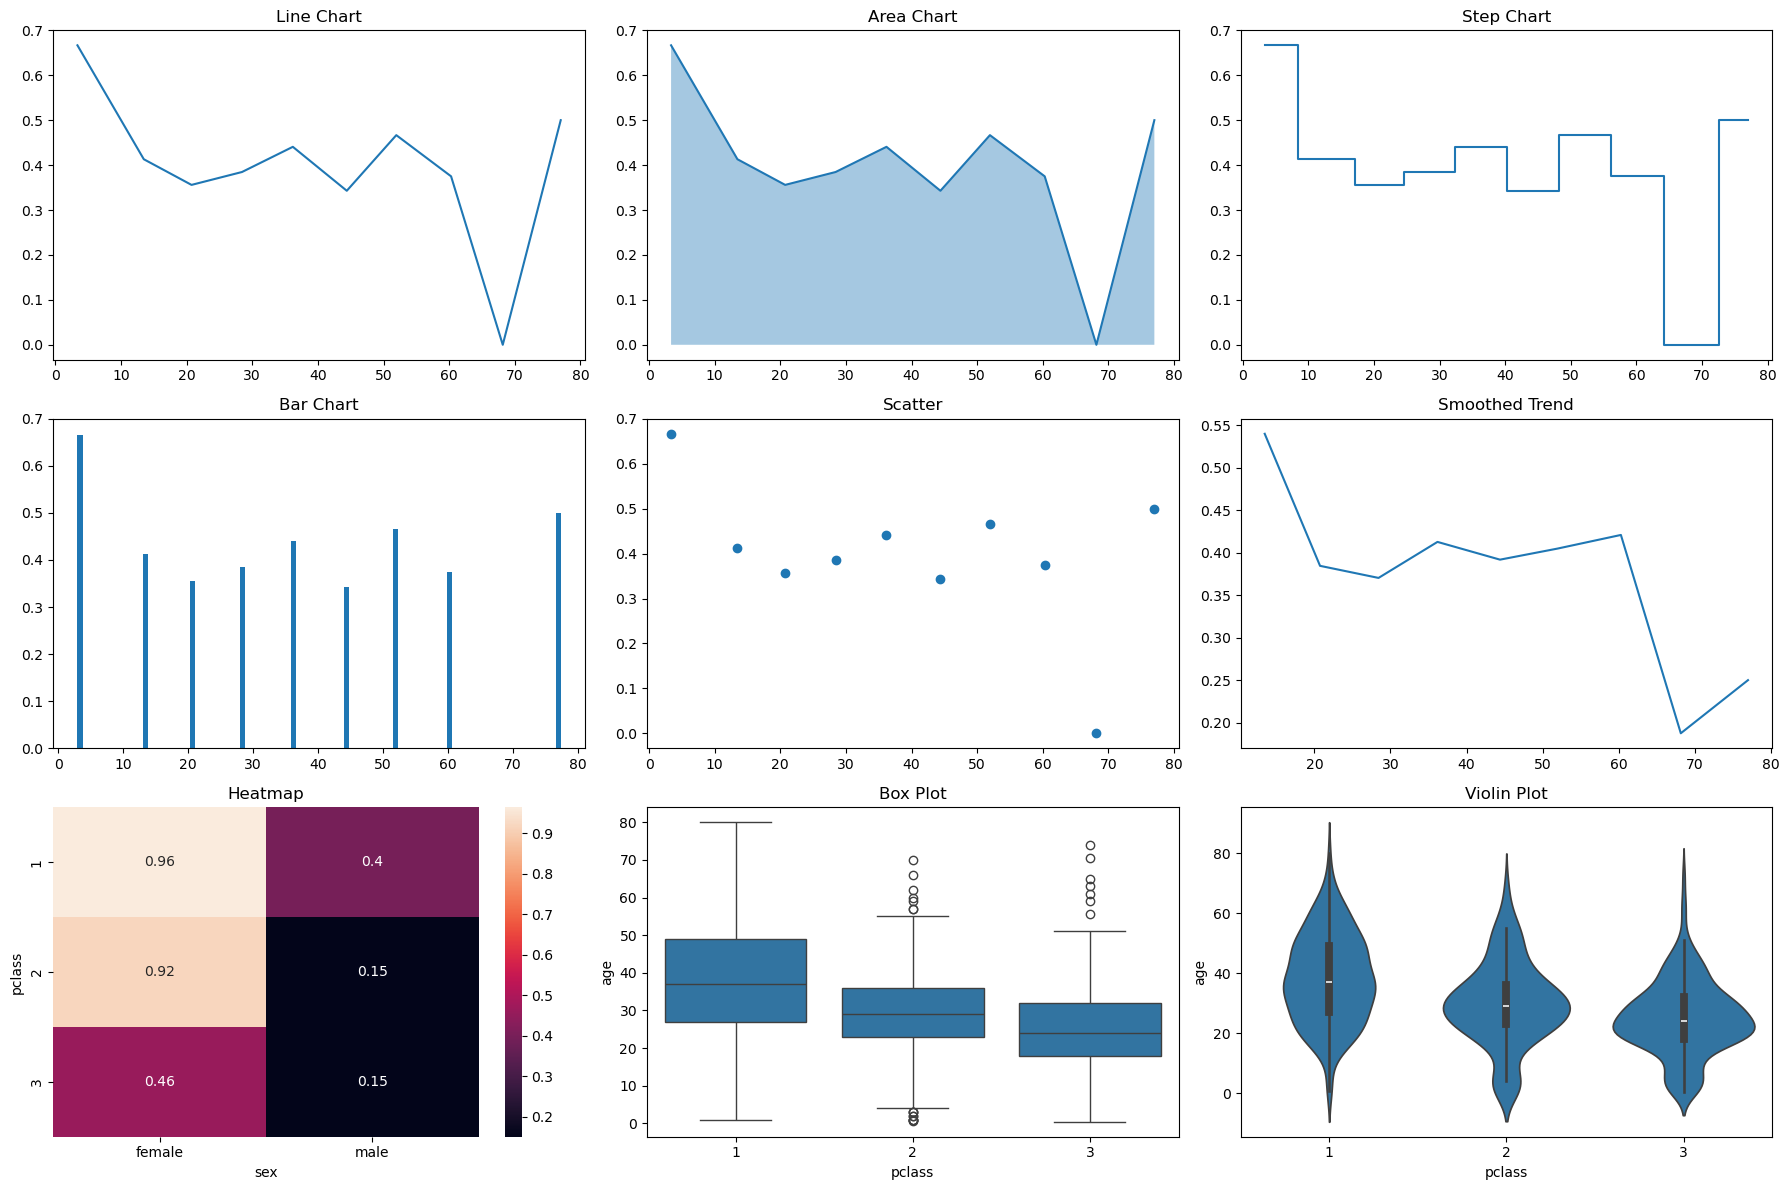

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = sns.load_dataset("titanic")

# Drop missing
df = df.dropna(subset=["age", "fare"])

# Create age bins (pseudo-time)
df["age_bin"] = pd.cut(df["age"], bins=10)

# Aggregate
agg = df.groupby("age_bin").agg({
    "survived": "mean",
    "fare": "mean",
    "age": "mean"
}).reset_index()

# Convert bin to numeric midpoint
agg["age_mid"] = agg["age"]

# -----------------------------
# Create subplot grid (3x3)
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# 1. Line Chart (baseline)
axes[0,0].plot(agg["age_mid"], agg["survived"])
axes[0,0].set_title("Line Chart")

# 2. Area Chart
axes[0,1].fill_between(agg["age_mid"], agg["survived"], alpha=0.4)
axes[0,1].plot(agg["age_mid"], agg["survived"])
axes[0,1].set_title("Area Chart")

# 3. Step Chart
axes[0,2].step(agg["age_mid"], agg["survived"], where='mid')
axes[0,2].set_title("Step Chart")

# 4. Bar Chart (time-like)
axes[1,0].bar(agg["age_mid"], agg["survived"])
axes[1,0].set_title("Bar Chart")

# 5. Scatter Plot
axes[1,1].scatter(agg["age_mid"], agg["survived"])
axes[1,1].set_title("Scatter")

# 6. Smoothed Line (rolling)
agg["smooth"] = agg["survived"].rolling(2).mean()
axes[1,2].plot(agg["age_mid"], agg["smooth"])
axes[1,2].set_title("Smoothed Trend")

# 7. Heatmap (pivot)
pivot = df.pivot_table(values="survived", index="pclass", columns="sex")
sns.heatmap(pivot, annot=True, ax=axes[2,0])
axes[2,0].set_title("Heatmap")

# 8. Box Plot (distribution over pseudo-time)
sns.boxplot(data=df, x="pclass", y="age", ax=axes[2,1])
axes[2,1].set_title("Box Plot")

# 9. Violin Plot
sns.violinplot(data=df, x="pclass", y="age", ax=axes[2,2])
axes[2,2].set_title("Violin Plot")

# Layout fix
plt.tight_layout()
plt.show()